In [1]:
import sys
sys.path.append('../')

from BPMQ import *
import numpy as np
import datetime
import matplotlib.pyplot as plt
from flame_utils import ModelFlame
from epics import caget

In [2]:
machineIO = construct_machineIO()
machineIO._test = False
machineIO._check_chopper_blocking = False
machineIO._fetch_data_time_span = 3
machineIO._ensure_set_timewait_after_ramp = 0.25
machineIO._fetch_data_resample_rate = 0.2

E_MeVu = 175
Charge_number = 20

SCS = caget("ACS_DIAG:DEST:ACTIVE_ION_SOURCE")
Mass_number = caget("FE_ISRC"+str(SCS)+":BEAM:A_BOOK")
Ion = caget("FE_ISRC"+str(SCS)+":BEAM:ELMT_BOOK")

FLAMEfile = "flame_reconst_input_20250226_00_48Ca20+.lat"  # Replace with your lattice file
from_elem = "BDS_BTS:QV_D5501"
to_elem = "BDS_BTS:PM_D5567"

In [3]:
fname = datetime.datetime.now().strftime('%Y%m%d_%H%M')+f'_{Mass_number}{Ion}{Charge_number}+_3xPM3yPM'
fname

'20250226_0053_48Ca20+_3xPM3yPM'

In [4]:
lattice_dicts = fmlat.combine_lattice_elements_quads_only(FLAMEfile, from_element=from_elem, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])
qnames = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
qnames = qnames[-4:]
qnames

['BDS_BTS:PSQ_D5501',
 'BDS_BTS:PSQ_D5509',
 'BDS_BTS:PSQ_D5552',
 'BDS_BTS:PSQ_D5559']

In [5]:
fm = ModelFlame(FLAMEfile)
from_index = fm.get_element(from_elem)[0]['index']
r,s = fm.run(to_element=from_index-1)
alfx,betx = s.get_twiss('x')[:2]
emitxn = s.xnemittance
alfy,bety = s.get_twiss('y')[:2]
emityn = s.ynemittance

cs_ref = [alfx, betx, emitxn*1e-6,alfy, bety, emityn*1e-6]
cs_ref

[-3.7026266229490896,
 21.916082993951377,
 5.754009737477061e-07,
 0.23082760990744372,
 8.739429635139988,
 4.03489198434486e-07]

In [6]:
args = (E_MeVu, Mass_number, Charge_number)
kwargs = {
    "lattice_dicts" : lattice_dicts,
    "quads_to_scan": ["BDS_BTS:PSQ_D5501", "BDS_BTS:PSQ_D5509", "BDS_BTS:PSQ_D5552", "BDS_BTS:PSQ_D5559"],
    "quads_max_curr": [180, 180, 180, 180],
    "quads_min_curr": [ 10,  10,  10,  10],
    "xnemit_target": None,#emitxn,
    "ynemit_target": None,#emityn,
    "BPM_names":["BDS_BTS:BPM_D5513", "BDS_BTS:BPM_D5565"],
    "BPMQ_model_type":"TIS161_GP",
    "ISAAC_preset_keywords":["BDS"],
    "machineIO": machineIO,
    "bootstrap":False,
    "plot_history":True, 
    "plot_ellipse":True,
    "set_manually":True,
    "correct_traj_each_iter":False,
    "cs_ref": cs_ref,
    
}

 ======== cs_reconstruct ========


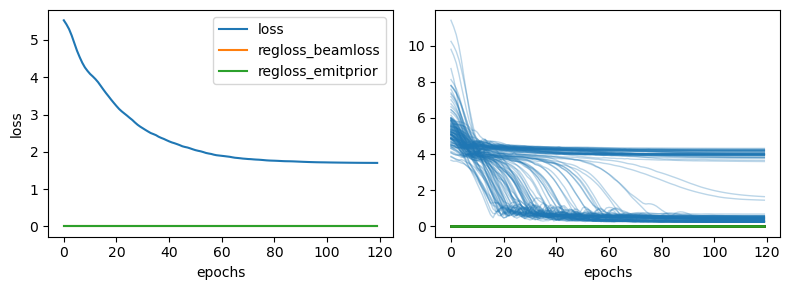

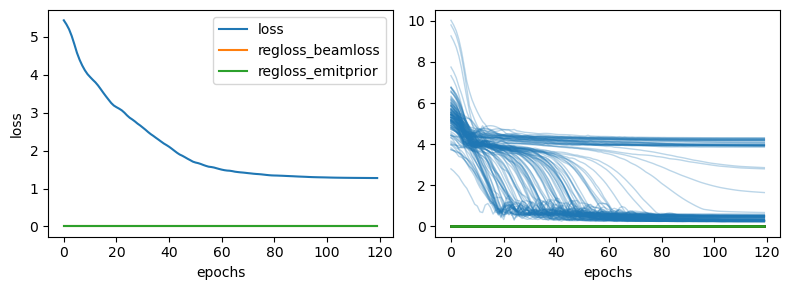

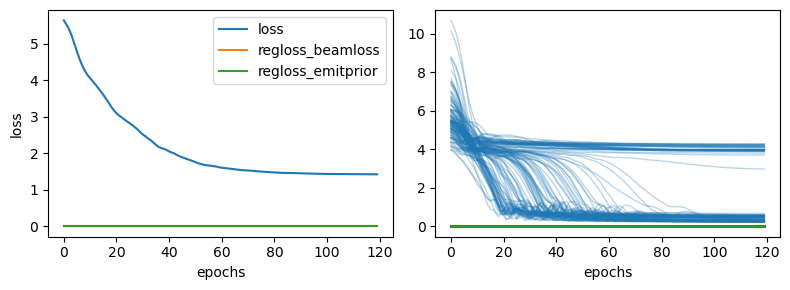

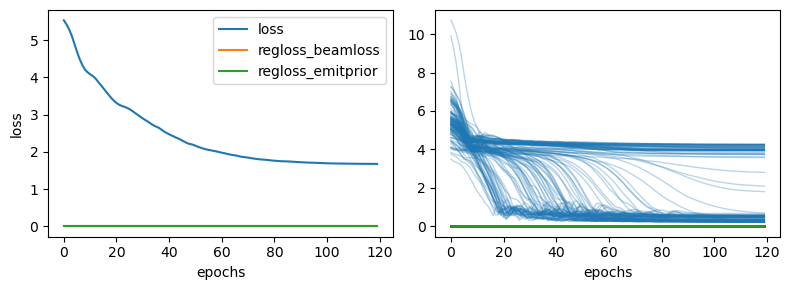

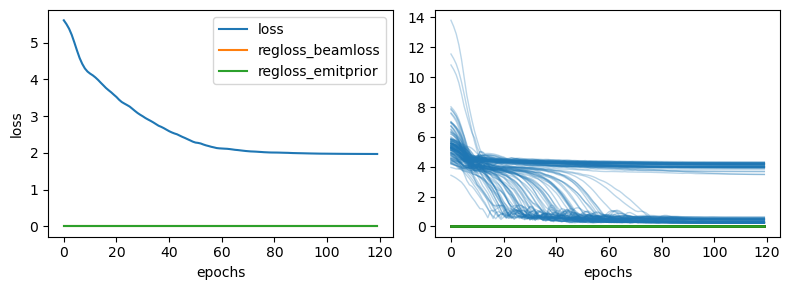

Elapsed time: 0.11 minutes


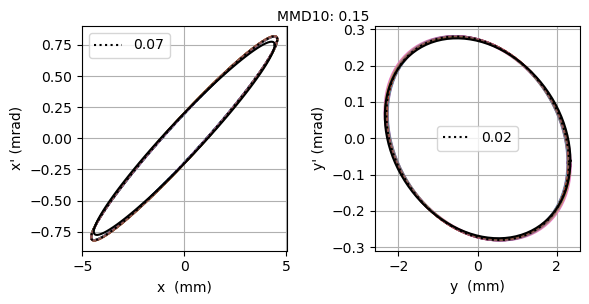

In [7]:
start_time = time.monotonic()

bpmQscan = BPMQscan(*args, **kwargs)
lxrms,lyrms,reltol = np.array([5.384]), np.array([1.618]), 0.01
bpmQscan.concat_PM_train_data(quads_curr = [76.306, 81.936, 106.99, 123.957], 
                              lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
lxrms,lyrms,reltol = np.array([1.016]), np.array([1.424]), 0.01
bpmQscan.concat_PM_train_data(quads_curr = [76.306, 104.330, 106.99, 123.957], 
                              lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
lxrms,lyrms,reltol = np.array([6.579]), np.array([1.579]), 0.01
bpmQscan.concat_PM_train_data(quads_curr = [76.306, 126.694, 106.99, 123.957], 
                              lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
lxrms,lyrms,reltol = np.array([7.023]), np.array([2.53]), 0.01
bpmQscan.concat_PM_train_data(quads_curr = [96.4, 84.311, 106.99, 123.957], 
                              lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
lxrms,lyrms,reltol = np.array([3.478]), np.array([1.35]), 0.01
bpmQscan.concat_PM_train_data(quads_curr = [66.6, 84.311, 106.99, 123.957], 
                              lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)
lxrms,lyrms,reltol = np.array([1.339]), np.array([2.366]), 0.01
bpmQscan.concat_PM_train_data(quads_curr = [36.8, 84.311, 106.99, 123.957], 
                              lxrms=lxrms,lyrms=lyrms,lxrmstol=lxrms*reltol,lyrmstol=lyrms*reltol)

bpmQscan.train_model()
# bpmQscan.run(budget=6)
elapsed_time_minutes = (time.monotonic() - start_time) / 60
print(f"Elapsed time: {elapsed_time_minutes:.2f} minutes")

In [8]:
# plt.plot(bpmQscan.evaluated_dfs[0][0]['BDS_BTS:BPM_D5513:TISRAW3_RD'].iloc[0])

In [13]:

# l_xcovs, l_ycovs = fmlat.update_lattice_file_from_bpmQscan(fname+'.lat',bpmQscan)

FileNotFoundError: [Errno 2] No such file or directory: '20250226_0053_48Ca20+_3xPM3yPM.lat'

In [10]:
bpmQscan.save_data(fname+'.pkl')

In [11]:
bpmQscan.model.cs.detach().cpu().numpy()

array([-4.0114756e+00,  2.3032127e+01,  5.7961842e-07,  2.4477440e-01,
        8.4785862e+00,  4.0276151e-07], dtype=float32)